# Viterbi Transition-Weight Tuning — match the human's hand smoothness

Companion to **`AudioToTabCAGED (2).ipynb`**. The playability analysis found predicted tabs are physically valid (99.3%) but **35% jumpier** than expert ground truth (avg fret-jump 1.42 vs 1.05; large-jump rate 4.5% vs 1.0%). The mechanism is in the CAGED Viterbi transition cost:

```
base_trans = hand_move * max(Δ−SHIFT_FREE, 0) + 0.5 * max(Δ−LARGE_JUMP_THRESHOLD, 0)²
step_trans = base_trans            if near a chord
           = base_trans * SOLO_MOVE_SCALE   between single notes   ← relaxes solo movement to 35%
```

Two accessible knobs: **`CAGED_WEIGHTS['hand_move']`** (0.70 — the linear movement penalty) and **`SOLO_MOVE_SCALE`** (0.35 — how much solo movement is let off the leash). This notebook sweeps both on validation, tracking **both** the movement parity (pred/GT jump ratio → 1.0) and **`exact_tab_f1`/TDR**, to answer the real question: *does enforcing the human's smoothness also recover the human's specific string choices?*

**Efficiency:** detection + key/chord context don't depend on the weights, so they're computed **once per record** and cached; each grid cell only re-runs the assignment. The matched note-set is identical across settings (matching is by pitch+onset, not string), so this cleanly isolates the assignment effect.

**Discipline:** sweep on `VAL_RECORDS`, report on `TEST_RECORDS` once.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Run pipeline + pair audio

In [3]:
from pathlib import Path
PIPELINE_NB = '/content/drive/MyDrive/Capstone/Code/AudioToTabCAGEDVoice.ipynb'
assert Path(PIPELINE_NB).exists(), f"Not found: {PIPELINE_NB}"
%run "/content/drive/MyDrive/Capstone/Code/AudioToTabCAGEDVoice.ipynb"

import numpy as np, pandas as pd, __main__ as M

for nm in ['assign_caged_voiced','make_audio_record_from_gt','enrich_notes_with_context',
           'match_audio_predictions_to_truth','parse_key','get_possible_positions',
           'CAGED_WEIGHTS','SOLO_MOVE_SCALE','VAL_RECORDS','TEST_RECORDS','find_audio_for_record',
           'AUDIO_MATCH_ONSET_TOLERANCE_SECONDS','OPEN_STRING_MIDI']:
    assert nm in dir(), f"missing {nm} after %run"

DEFAULT_HAND_MOVE  = CAGED_WEIGHTS['hand_move']     # 0.70
DEFAULT_SOLO_SCALE = SOLO_MOVE_SCALE                # 0.35
print(f"Defaults: hand_move={DEFAULT_HAND_MOVE}, SOLO_MOVE_SCALE={DEFAULT_SOLO_SCALE}")

def pair(records):
    out=[]
    for r in records:
        ap=find_audio_for_record(r)
        if ap is not None: out.append((r,ap))
    return out
paired_val, paired_test = pair(VAL_RECORDS), pair(TEST_RECORDS)
print(f"Paired val={len(paired_val)}  test={len(paired_test)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.
OUTPUT_DIR: /content/drive/MyDrive/Capstone/outputs/fretboard_playability
OUTPUT_DIR exists: True

Data root candidates visible to this runtime:
 - /content/drive/MyDrive/Capstone/FullGuitarSetData | exists: True
 - /content/drive/MyDrive/FullGuitarSetData | exists: False
 - /content/drive/MyDrive/Capstone/GuitarSet | exists: True
 - /content/drive/MyDrive/GuitarSet | exists: False
 - /content/drive/MyDrive/Capstone | exists: True
 - /content/drive/MyDrive | exists: True
 - /mnt/data/fretwork_repo/GuitarSet | exists: False
 - /mnt/data/fretwork_repo | exists: False

Top-level MyDrive folders/files visible to Colab:
 - labels.csv
 - yelp_dataset.tar
 - Spring 2025
 - Tell a compelling story. Example. Fall 2020. Airline Pricing.gdoc
 - DATASCI200 Project Proposal.gdoc
 - personalized bus routes.fall 2024.gdoc
 - Final Report T

,string,string_name,fret,midi,pitch_class
0,0,low_E,0,40,4
1,0,low_E,1,41,5
2,0,low_E,2,42,6
3,0,low_E,3,43,7
4,0,low_E,4,44,8
5,0,low_E,5,45,9
6,0,low_E,6,46,10
7,0,low_E,7,47,11
8,0,low_E,8,48,0
9,0,low_E,9,49,1


Example positions for MIDI 64 / E4:


,string,string_name,fret,midi,pitch_class
0,0,low_E,24,64,4
1,1,A,19,64,4
2,2,D,14,64,4
3,3,G,9,64,4
4,4,B,5,64,4
5,5,high_E,0,64,4


,key,root,root_pc,mode,scale_pcs,scale_notes,diatonic_chords
0,C major,C,0,major,"[0, 2, 4, 5, 7, 9, 11]","[C, D, E, F, G, A, B]","[{'degree': 1, 'root_pc': 0, 'root': 'C', 'qua..."
1,C minor,C,0,minor,"[0, 2, 3, 5, 7, 8, 10]","[C, D, D#, F, G, G#, A#]","[{'degree': 1, 'root_pc': 0, 'root': 'C', 'qua..."
2,C# major,C#,1,major,"[1, 3, 5, 6, 8, 10, 0]","[C#, D#, F, F#, G#, A#, C]","[{'degree': 1, 'root_pc': 1, 'root': 'C#', 'qu..."
3,C# minor,C#,1,minor,"[1, 3, 4, 6, 8, 9, 11]","[C#, D#, E, F#, G#, A, B]","[{'degree': 1, 'root_pc': 1, 'root': 'C#', 'qu..."
4,D major,D,2,major,"[2, 4, 6, 7, 9, 11, 1]","[D, E, F#, G, A, B, C#]","[{'degree': 1, 'root_pc': 2, 'root': 'D', 'qua..."


...


REAL AUDIO → BASIC PITCH → ALGORITHM TAB
REAL AUDIO PREDICTED TAB — 05_SS2-88-F_solo — combined_all_tuned
----------------------------------------------------------------
e|---------6--8--9--6-----|------------------------|------------------------|------------------------|
B|---------6-----------6--|---------6--------------|------------9--11-9--8--|6-----------------6--9--|
G|------------------------|------------8-----------|---------8--------------|------------------------|
D|------------------------|------------------------|------------------------|------------------------|
A|------------------------|------------------------|------------------------|------------------------|
E|------------------------|------------------------|------------------------|------------------------|

e|------------------------|------------------------|------------------------|------------------5--8--|
B|8--------------8--------|------------------8--6--|6-----------------6-----|------------------6-----|
G|-

,method,recordings,n_gt_notes,n_basic_pitch_notes,pitch_precision,pitch_recall,pitch_f1,exact_tab_precision,exact_tab_recall,exact_tab_f1,tab_accuracy_given_pitch_match,string_accuracy_given_pitch_match,fret_accuracy_given_pitch_match,mean_runtime_sec_per_recording
1,caged_voiced,54,10207,9561,0.802,0.7512,0.7758,0.5549,0.5197,0.5367,0.6918,0.6918,0.6918,0.6975
0,caged_box,54,10207,9561,0.802,0.7512,0.7758,0.5497,0.5149,0.5318,0.6854,0.6854,0.6854,1.8525
2,combined_all_tuned,54,10207,9561,0.802,0.7512,0.7758,0.5191,0.4862,0.5021,0.6472,0.6472,0.6472,0.7076



Saved report table to: /content/drive/MyDrive/Capstone/outputs/audio_to_tab_basic_pitch_heldout/audio_to_tab_report_table_heldout_test.csv

Interpretation:
The previous held-out result measured fretboard assignment using ground-truth GuitarSet notes.
This result starts from raw audio, runs Basic Pitch first, then predicts string/fret positions.
So exact_tab_f1 is the stricter end-to-end audio-to-tab metric.
Matched notes (detected + pitch-correct): 7668
  exact-correct placement : 5256  (68.5%)
  wrong placement         : 2412  (31.5%)

Of the WRONG notes — how many strings off:
  |Δstring|=1:  2309  (95.7%)  ADJACENT (one string off)
  |Δstring|=2:    88  ( 3.6%)  two strings off
  |Δstring|=3:    14  ( 0.6%)  three strings off
  |Δstring|=5:     1  ( 0.0%)  5 off

>>> 95.7% of wrong notes are exactly ONE string off (adjacent).
>>> That's 30.1% of all matched notes (the rest place correctly or miss by 2+ strings).

Fret-diff distribution (sanity: adjacent swaps cluster at ±4/±5):
fre

slice,ALL,comp,solo
method,,,
caged_box,0.6854,0.7199,0.6105
caged_voiced,0.6918,0.7308,0.6072
combined_all_tuned,0.6472,0.6677,0.6026


Defaults: hand_move=0.7, SOLO_MOVE_SCALE=0.35
Paired val=54  test=54


## 2. Precompute detection + context once per record

The slow part (Basic Pitch + key/chord detection) runs here, once. The sweep then only touches the assignment. ~couple minutes for validation.

In [4]:
def build_context_cache(paired):
    cache=[]
    for k,(record,audio_path) in enumerate(paired):
        arec = make_audio_record_from_gt(record, audio_path)
        enr  = enrich_notes_with_context(arec)
        enr  = [n for n in enr if get_possible_positions(n['midi'])]
        key  = parse_key(enr[0].get('key_label')) if enr else None
        cache.append({'record':record, 'notes':enr, 'key':key})
        if (k+1)%15==0: print(f"  context {k+1}/{len(paired)}")
    return cache

print("Building validation context cache...")
ctx_val  = build_context_cache(paired_val)
print("Building test context cache...")
ctx_test = build_context_cache(paired_test)
print("Done.")

Building validation context cache...
Running Basic Pitch on: 02_Funk3-98-A_solo_mic.wav
Predicting MIDI for /content/drive/MyDrive/Capstone/FullGuitarSetData/AudioFiles/02_Funk3-98-A_solo_mic.wav...
Running Basic Pitch on: 00_Jazz2-187-F#_comp_mic.wav
Predicting MIDI for /content/drive/MyDrive/Capstone/FullGuitarSetData/AudioFiles/00_Jazz2-187-F#_comp_mic.wav...
Running Basic Pitch on: 00_BN3-154-E_comp_mic.wav
Predicting MIDI for /content/drive/MyDrive/Capstone/FullGuitarSetData/AudioFiles/00_BN3-154-E_comp_mic.wav...
Running Basic Pitch on: 01_Rock1-90-C#_solo_mic.wav
Predicting MIDI for /content/drive/MyDrive/Capstone/FullGuitarSetData/AudioFiles/01_Rock1-90-C#_solo_mic.wav...
Running Basic Pitch on: 01_BN2-166-Ab_comp_mic.wav
Predicting MIDI for /content/drive/MyDrive/Capstone/FullGuitarSetData/AudioFiles/01_BN2-166-Ab_comp_mic.wav...
Running Basic Pitch on: 05_Rock1-130-A_solo_mic.wav
Predicting MIDI for /content/drive/MyDrive/Capstone/FullGuitarSetData/AudioFiles/05_Rock1-130-A_s

## 3. Movement scorer (grips → fret-jumps), same definitions as the playability notebook

In [5]:
ONSET_TOL=0.05; BIG_JUMP=4
def grip_groups(times, tol=ONSET_TOL):
    order=np.argsort(times); ts=np.asarray(times)[order]
    groups,cur,anchor=[],[order[0]],ts[0]
    for k in range(1,len(order)):
        if ts[k]-anchor<=tol: cur.append(order[k])
        else: groups.append(cur); cur=[order[k]]; anchor=ts[k]
    groups.append(cur); return groups

def avg_jump(df_rec, string_col, fret_col):
    d=df_rec.dropna(subset=[string_col,fret_col,'gt_start']).reset_index(drop=True)
    if len(d)<2: return np.nan, np.nan, 0
    groups=grip_groups(d['gt_start'].values); positions=[]
    for g in groups:
        fr=d.iloc[list(g)][fret_col].astype(float).values
        fingered=fr[fr>0]
        positions.append(float(np.mean(fingered)) if len(fingered) else np.nan)
    pos=pd.Series(positions).dropna().values
    if len(pos)<2: return np.nan, np.nan, 0
    j=np.abs(np.diff(pos))
    return j.mean(), (j>BIG_JUMP).mean(), len(j)

## 4. Evaluate one weight setting on a context cache

Sets the two globals, re-runs only the assignment, matches, and pools `exact_tab_f1`, TDR, and movement (pred & true).

In [6]:
def eval_setting(ctx, hand_move, solo_scale):
    M.CAGED_WEIGHTS['hand_move'] = hand_move     # mutate in place (default-arg dict object)
    M.SOLO_MOVE_SCALE = solo_scale               # rebind module global (looked up at call time)
    per_rec=[]; all_m=[]
    for item in ctx:
        notes=item['notes']
        assigned = assign_caged_voiced(notes, key=item['key']) if notes else []
        for r in assigned: r['recording']=item['record']['recording']
        matches,pred_all,gt_all = match_audio_predictions_to_truth(
            assigned, item['record']['notes'],
            onset_tolerance=AUDIO_MATCH_ONSET_TOLERANCE_SECONDS, require_pitch=True)
        mdf=pd.DataFrame(matches)
        tp=int(mdf['exact_tab_correct'].sum()) if len(mdf) else 0
        per_rec.append({'n_pred':len(pred_all),'n_gt':len(gt_all),'tp':tp,'n_match':len(matches)})
        if len(mdf):
            mdf['recording']=item['record']['recording']; all_m.append(mdf)
    R=pd.DataFrame(per_rec)
    tp,npr,ngt=R['tp'].sum(),R['n_pred'].sum(),R['n_gt'].sum()
    P=tp/npr if npr else 0; Rec=tp/ngt if ngt else 0
    f1=2*P*Rec/(P+Rec) if (P+Rec) else 0
    matches_all=pd.concat(all_m, ignore_index=True) if all_m else pd.DataFrame()
    tdr=float(matches_all['exact_tab_correct'].mean()) if len(matches_all) else np.nan
    # movement pred vs true, pooled across recordings (weight by transitions)
    jp=jt=lp=lt=wsum_p=wsum_t=0.0
    for rec,g in matches_all.groupby('recording'):
        a_jp,a_lp,np_=avg_jump(g,'pred_string','pred_fret')
        a_jt,a_lt,nt_=avg_jump(g,'true_string','true_fret')
        if np_>0 and not np.isnan(a_jp): jp+=a_jp*np_; lp+=a_lp*np_; wsum_p+=np_
        if nt_>0 and not np.isnan(a_jt): jt+=a_jt*nt_; lt+=a_lt*nt_; wsum_t+=nt_
    jump_pred=jp/wsum_p if wsum_p else np.nan
    jump_true=jt/wsum_t if wsum_t else np.nan
    return {'hand_move':hand_move,'solo_scale':solo_scale,'exact_tab_f1':f1,'TDR':tdr,
            'jump_pred':jump_pred,'jump_true':jump_true,
            'jump_ratio':jump_pred/jump_true if jump_true else np.nan,
            'largejump_pred':lp/wsum_p if wsum_p else np.nan,
            'largejump_true':lt/wsum_t if wsum_t else np.nan}

## 5. Grid sweep on VALIDATION

`hand_move` ∈ {0.7…3.0}, `SOLO_MOVE_SCALE` ∈ {0.35…1.0}. The (0.70, 0.35) cell is your current default.

In [7]:
HAND_MOVE_GRID  = [0.7, 1.0, 1.5, 2.0, 3.0]
SOLO_SCALE_GRID = [0.35, 0.5, 0.7, 1.0]

rows=[]
for hm in HAND_MOVE_GRID:
    for ss in SOLO_SCALE_GRID:
        r=eval_setting(ctx_val, hm, ss)
        rows.append(r)
        tag=' (default)' if (hm==DEFAULT_HAND_MOVE and ss==DEFAULT_SOLO_SCALE) else ''
        print(f"  hand_move={hm:.1f} solo={ss:.2f} | exact_tab_f1={r['exact_tab_f1']:.4f} "
              f"TDR={r['TDR']:.4f} jump_ratio={r['jump_ratio']:.2f}{tag}")
val_grid=pd.DataFrame(rows)

# restore defaults so nothing downstream is affected
M.CAGED_WEIGHTS['hand_move']=DEFAULT_HAND_MOVE; M.SOLO_MOVE_SCALE=DEFAULT_SOLO_SCALE

  hand_move=0.7 solo=0.35 | exact_tab_f1=0.4885 TDR=0.6656 jump_ratio=1.27 (default)
  hand_move=0.7 solo=0.50 | exact_tab_f1=0.4885 TDR=0.6656 jump_ratio=1.26
  hand_move=0.7 solo=0.70 | exact_tab_f1=0.4887 TDR=0.6659 jump_ratio=1.26
  hand_move=0.7 solo=1.00 | exact_tab_f1=0.4890 TDR=0.6664 jump_ratio=1.26
  hand_move=1.0 solo=0.35 | exact_tab_f1=0.4882 TDR=0.6652 jump_ratio=1.26
  hand_move=1.0 solo=0.50 | exact_tab_f1=0.4884 TDR=0.6655 jump_ratio=1.26
  hand_move=1.0 solo=0.70 | exact_tab_f1=0.4886 TDR=0.6658 jump_ratio=1.25
  hand_move=1.0 solo=1.00 | exact_tab_f1=0.4887 TDR=0.6659 jump_ratio=1.25
  hand_move=1.5 solo=0.35 | exact_tab_f1=0.4854 TDR=0.6614 jump_ratio=1.25
  hand_move=1.5 solo=0.50 | exact_tab_f1=0.4859 TDR=0.6621 jump_ratio=1.25
  hand_move=1.5 solo=0.70 | exact_tab_f1=0.4859 TDR=0.6621 jump_ratio=1.25
  hand_move=1.5 solo=1.00 | exact_tab_f1=0.4860 TDR=0.6623 jump_ratio=1.24
  hand_move=2.0 solo=0.35 | exact_tab_f1=0.4848 TDR=0.6607 jump_ratio=1.25
  hand_move=2.0

## 6. Read the grid — best TDR, and best smoothness without losing TDR

DEFAULT (0.70, 0.35): exact_tab_f1=0.4885  TDR=0.6656  jump_ratio=1.27

Max exact_tab_f1: hand_move=0.7, solo=1.0 -> f1=0.4890 TDR=0.6664 jump_ratio=1.26
Smoothest w/o f1 loss: hand_move=1.0, solo=0.7 -> f1=0.4886 TDR=0.6658 jump_ratio=1.25

Full validation grid (sorted by exact_tab_f1):


,hand_move,solo_scale,exact_tab_f1,TDR,jump_pred,jump_true,jump_ratio,largejump_pred
3,0.7,1.00,0.4890,0.6664,1.4894,1.184,1.2580,0.0369
2,0.7,0.70,0.4887,0.6659,1.4917,1.184,1.2599,0.0371
7,1.0,1.00,0.4887,0.6659,1.4848,1.184,1.2540,0.0360
6,1.0,0.70,0.4886,0.6658,1.4839,1.184,1.2533,0.0358
0,0.7,0.35,0.4885,0.6656,1.5011,1.184,1.2678,0.0392
1,0.7,0.50,0.4885,0.6656,1.4952,1.184,1.2629,0.0381
5,1.0,0.50,0.4884,0.6655,1.4888,1.184,1.2575,0.0365
4,1.0,0.35,0.4882,0.6652,1.4901,1.184,1.2585,0.0369
11,1.5,1.00,0.4860,0.6623,1.4721,1.184,1.2434,0.0337
9,1.5,0.50,0.4859,0.6621,1.4751,1.184,1.2459,0.0342


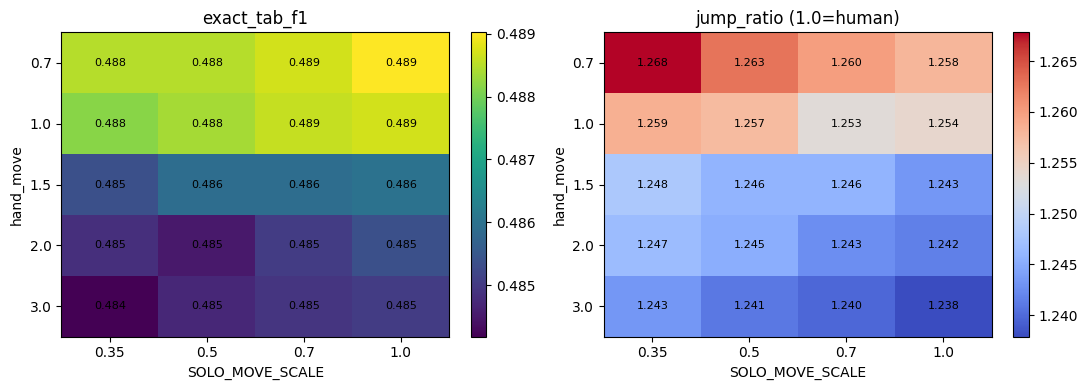

In [8]:
default_row = val_grid[(val_grid.hand_move==DEFAULT_HAND_MOVE)&(val_grid.solo_scale==DEFAULT_SOLO_SCALE)].iloc[0]
print(f"DEFAULT (0.70, 0.35): exact_tab_f1={default_row['exact_tab_f1']:.4f}  TDR={default_row['TDR']:.4f}  jump_ratio={default_row['jump_ratio']:.2f}")

best_tdr = val_grid.loc[val_grid['exact_tab_f1'].idxmax()]
print(f"\nMax exact_tab_f1: hand_move={best_tdr['hand_move']}, solo={best_tdr['solo_scale']} "
      f"-> f1={best_tdr['exact_tab_f1']:.4f} TDR={best_tdr['TDR']:.4f} jump_ratio={best_tdr['jump_ratio']:.2f}")

# smoothest setting that doesn't sacrifice exact_tab_f1 vs default
ok = val_grid[val_grid['exact_tab_f1'] >= default_row['exact_tab_f1'] - 1e-9].copy()
ok['ratio_dist']=(ok['jump_ratio']-1.0).abs()
best_smooth = ok.loc[ok['ratio_dist'].idxmin()]
print(f"Smoothest w/o f1 loss: hand_move={best_smooth['hand_move']}, solo={best_smooth['solo_scale']} "
      f"-> f1={best_smooth['exact_tab_f1']:.4f} TDR={best_smooth['TDR']:.4f} jump_ratio={best_smooth['jump_ratio']:.2f}")

print("\nFull validation grid (sorted by exact_tab_f1):")
display(val_grid.sort_values('exact_tab_f1', ascending=False)
        [['hand_move','solo_scale','exact_tab_f1','TDR','jump_pred','jump_true','jump_ratio','largejump_pred']].round(4))

import matplotlib.pyplot as plt
piv_f1=val_grid.pivot(index='hand_move',columns='solo_scale',values='exact_tab_f1')
piv_jr=val_grid.pivot(index='hand_move',columns='solo_scale',values='jump_ratio')
fig,ax=plt.subplots(1,2,figsize=(11,4))
for a,(piv,ttl,cm) in zip(ax,[(piv_f1,'exact_tab_f1','viridis'),(piv_jr,'jump_ratio (1.0=human)','coolwarm')]):
    im=a.imshow(piv.values,cmap=cm,aspect='auto'); a.set_xticks(range(len(piv.columns))); a.set_xticklabels(piv.columns)
    a.set_yticks(range(len(piv.index))); a.set_yticklabels(piv.index); a.set_xlabel('SOLO_MOVE_SCALE'); a.set_ylabel('hand_move'); a.set_title(ttl)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]): a.text(j,i,f'{piv.values[i,j]:.3f}',ha='center',va='center',fontsize=8)
    plt.colorbar(im,ax=a,fraction=0.046)
plt.tight_layout(); plt.show()

## 7. Report on TEST once — chosen setting vs default

Set `CHOSEN` from Section 6 (default uses max-exact_tab_f1; switch to the smoothest-without-loss pick if you'd rather prioritize human-like phrasing).

In [9]:
CHOSEN = (float(best_tdr['hand_move']), float(best_tdr['solo_scale']))   # or (float(best_smooth['hand_move']), float(best_smooth['solo_scale']))
print("Chosen (hand_move, solo_scale):", CHOSEN)

res_chosen  = eval_setting(ctx_test, CHOSEN[0], CHOSEN[1])
res_default = eval_setting(ctx_test, DEFAULT_HAND_MOVE, DEFAULT_SOLO_SCALE)
M.CAGED_WEIGHTS['hand_move']=DEFAULT_HAND_MOVE; M.SOLO_MOVE_SCALE=DEFAULT_SOLO_SCALE  # restore

cmp=pd.DataFrame([{'config':f'tuned {CHOSEN}', **res_chosen},
                  {'config':f'default ({DEFAULT_HAND_MOVE},{DEFAULT_SOLO_SCALE})', **res_default}])
print("\nTEST — caged_voiced:")
display(cmp[['config','exact_tab_f1','TDR','jump_pred','jump_true','jump_ratio','largejump_pred']].round(4))

print("\n"+"="*60)
print(f"exact_tab_f1: {res_default['exact_tab_f1']:.4f} -> {res_chosen['exact_tab_f1']:.4f} "
      f"({res_chosen['exact_tab_f1']-res_default['exact_tab_f1']:+.4f})")
print(f"TDR:          {res_default['TDR']:.4f} -> {res_chosen['TDR']:.4f} "
      f"({res_chosen['TDR']-res_default['TDR']:+.4f})")
print(f"jump_ratio:   {res_default['jump_ratio']:.2f} -> {res_chosen['jump_ratio']:.2f}  (target 1.0)")
print(f"large-jump:   {res_default['largejump_pred']:.3f} -> {res_chosen['largejump_pred']:.3f} "
      f"(human {res_chosen['largejump_true']:.3f})")
print("="*60)
d_tdr=res_chosen['TDR']-res_default['TDR']; d_jr=abs(res_chosen['jump_ratio']-1)-abs(res_default['jump_ratio']-1)
if d_tdr>0.003 and d_jr<0:
    print("WIN: smoother AND more accurate — matching human phrasing recovered string choices.")
elif d_jr<-0.05 and d_tdr>=-0.003:
    print("Smoother with no accuracy cost — cleaner tabs for free. Adopt it.")
elif d_tdr>0.003:
    print("More accurate; smoothness ~unchanged. Still a win on the metric that matters.")
else:
    print("Flat/tradeoff — the default weights were already near-optimal. Reportable null.")

Chosen (hand_move, solo_scale): (0.7, 1.0)

TEST — caged_voiced:


,config,exact_tab_f1,TDR,jump_pred,jump_true,jump_ratio,largejump_pred
0,"tuned (0.7, 1.0)",0.5348,0.6894,1.4108,1.0544,1.3380,0.0444
1,"default (0.7,0.35)",0.5367,0.6918,1.4205,1.0544,1.3472,0.0454



exact_tab_f1: 0.5367 -> 0.5348 (-0.0019)
TDR:          0.6918 -> 0.6894 (-0.0025)
jump_ratio:   1.35 -> 1.34  (target 1.0)
large-jump:   0.045 -> 0.044 (human 0.010)
Flat/tradeoff — the default weights were already near-optimal. Reportable null.


## 8. (Optional) Apply the tuned weights in your pipeline

If you adopt the tuned setting, set these at the top of your CAGED config (cell 36) so all eval + ASCII export use them:

```python
CAGED_WEIGHTS['hand_move'] = <chosen hand_move>
SOLO_MOVE_SCALE            = <chosen solo_scale>
```

Then re-run your end-to-end eval cell to refresh `audio_summary_df` and the ASCII tabs with the smoother assignment.